In [1]:
import cv2
import skimage
import numpy as np

print(cv2.__version__)
print(skimage.__version__)

5.0.0
0.26.0


In [2]:
from pathlib import Path

data_dir = Path(r"F:\Computer Vision\Test images for computer vision code")
image_files = sorted(data_dir.glob("*.tif"))

img_cv = cv2.imread(str(image_files[0]))
print(img_cv.shape, img_cv.dtype)
print(img_cv[300, 500])

(656, 1280, 3) uint8
[123 123 118]


In [3]:
red = img_cv[:, :, 2]
print(red.min(), red.max(), red.mean())

_, mask_cv = cv2.threshold(red, 109, 255, cv2.THRESH_BINARY_INV)
print(mask_cv.dtype, np.unique(mask_cv))
print((mask_cv == 255).sum(), "foreground pixels")

0 182 137.58858255525914
uint8 [  0 255]
153372 foreground pixels


In [4]:
mask_np = red < 110
print(np.array_equal(mask_np, mask_cv == 255))

True


In [5]:
import matplotlib.image as mpimg

img_mpl = mpimg.imread(str(image_files[0]))
red_mpl = img_mpl[:, :, 0]

diff = np.abs(red_mpl.astype(int) - red.astype(int))
print(diff.max(), (diff > 0).sum())

1 116759


In [6]:
contours, hierarchy = cv2.findContours(mask_cv, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_NONE)
outer = [c for c, h in zip(contours, hierarchy[0]) if h[3] == -1]
print(len(contours), len(outer))

531 203


In [7]:
areas = [cv2.contourArea(c) for c in outer]
print(sorted(areas, reverse=True)[:5])
print(sum(a == 0 for a in areas), "contours with zero area")

[153647.5, 868.0, 352.5, 331.0, 324.5]
153 contours with zero area


In [8]:
min_area, max_area = 5, 2500
droplets = [c for c in outer if min_area <= cv2.contourArea(c) <= max_area]
print(len(droplets), "droplet candidates")

24 droplet candidates


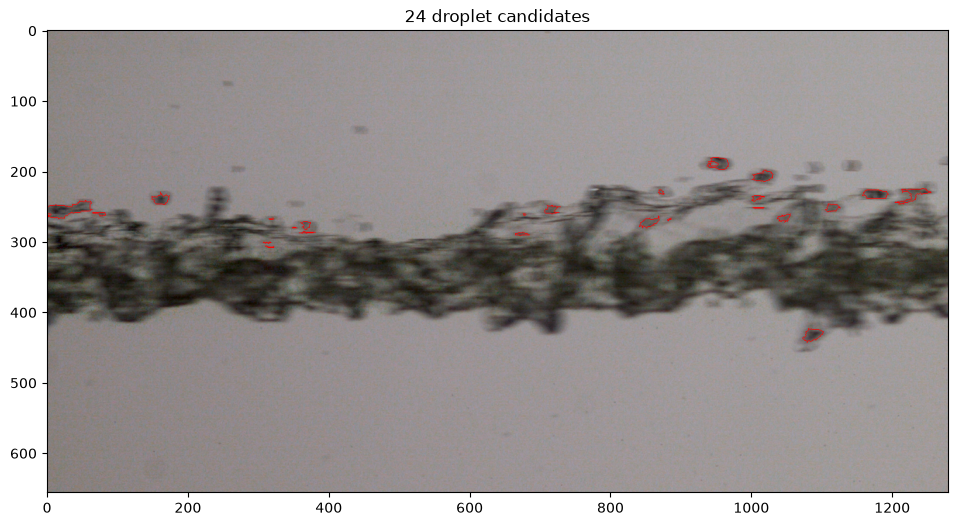

In [9]:
import matplotlib.pyplot as plt

overlay = img_cv.copy()
cv2.drawContours(overlay, droplets, -1, (0, 0, 255), 1)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{len(droplets)} droplet candidates")
plt.show()

In [10]:
n, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_cv, connectivity=8)
pix = stats[1:, cv2.CC_STAT_AREA]

print(n - 1, "regions")
print(((pix >= 5) & (pix <= 2500)).sum(), "pass 5-2500 as pixel counts")
print(((pix >= 5) & (pix <= 13)).sum(), "of those are 13 pixels or smaller")

203 regions
42 pass 5-2500 as pixel counts
20 of those are 13 pixels or smaller


In [11]:
from skimage.measure import regionprops
import pandas as pd

n, labels, stats, _ = cv2.connectedComponentsWithStats(mask_cv, connectivity=8)

rows = []
for r in regionprops(labels):
    if 5 <= r.area <= 2500:
        circ = 4 * np.pi * r.area / r.perimeter**2 if r.perimeter > 0 else 0
        rows.append(
            {
                "id": r.label,
                "area_px": r.area,
                "equiv_diameter_px": r.equivalent_diameter_area,
                "centroid_x": r.centroid[1],
                "centroid_y": r.centroid[0],
                "perimeter_px": r.perimeter,
                "circularity": circ,
            }
        )

df_droplets = pd.DataFrame(rows)
print(len(df_droplets))
print(df_droplets.round(2).head(10))
print(df_droplets[["area_px", "equiv_diameter_px", "circularity"]].describe().round(2))

42
   id  area_px  equiv_diameter_px  centroid_x  centroid_y  perimeter_px  \
0   1    372.0              21.76      954.38      188.37        114.18   
1   3    334.0              20.62     1017.04      206.80         85.53   
2   4     13.0               4.07      980.00      213.00         11.00   
3  10      8.0               3.19      928.38      221.88          8.41   
4  13    400.0              22.57     1230.37      232.44        176.64   
5  14     42.0               7.31      871.93      229.17         25.28   
6  16    393.0              22.37     1176.43      232.16         93.63   
7  17    276.0              18.75      161.73      239.51         76.73   
8  25     94.0              10.94     1008.12      237.16         53.97   
9  29      9.0               3.39      984.00      238.89          8.21   

   circularity  
0         0.36  
1         0.57  
2         1.35  
3         1.42  
4         0.16  
5         0.83  
6         0.56  
7         0.59  
8         0.41  
9

count    18.00
mean      0.47
std       0.15
min       0.16
25%       0.37
50%       0.46
75%       0.56
max       0.83
Name: circularity, dtype: float64


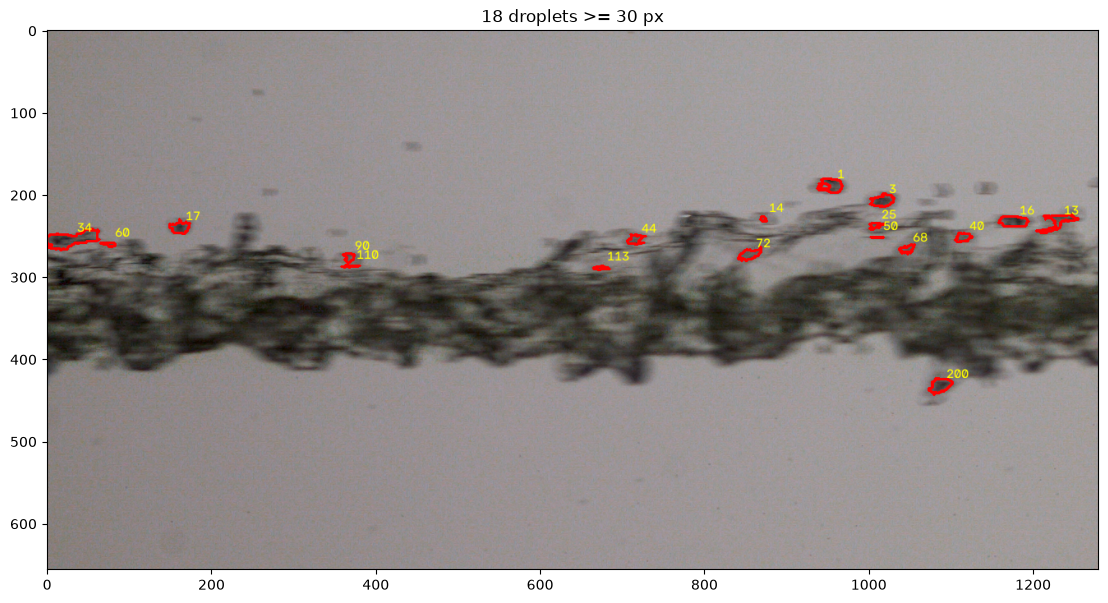

In [12]:
import matplotlib.pyplot as plt

MIN_CIRC_AREA = 30
df_droplets["circularity"] = df_droplets["circularity"].where(
    df_droplets["area_px"] >= MIN_CIRC_AREA
)
print(df_droplets["circularity"].describe().round(2))

big = df_droplets[df_droplets["area_px"] >= MIN_CIRC_AREA]
overlay = img_cv.copy()
for _, row in big.iterrows():
    m = (labels == int(row["id"])).astype(np.uint8)
    cs, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cv2.drawContours(overlay, cs, -1, (0, 0, 255), 2)
    cv2.putText(
        overlay,
        str(int(row["id"])),
        (int(row["centroid_x"]) + 8, int(row["centroid_y"]) - 8),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 255),
        1,
    )

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"{len(big)} droplets >= {MIN_CIRC_AREA} px")
plt.show()

In [13]:
from skimage.measure import regionprops
import pandas as pd


def measure_frame(filepath, threshold=110, min_area=5, max_area=2500, min_circ_area=30):
    img = cv2.imread(str(filepath))
    red = img[:, :, 2]
    mask = (red < threshold).astype(np.uint8)
    n, labels = cv2.connectedComponents(mask, connectivity=8)

    rows = []
    for r in regionprops(labels):
        if min_area <= r.area <= max_area:
            ok = r.perimeter > 0 and r.area >= min_circ_area
            rows.append(
                {
                    "filename": filepath.name,
                    "id": r.label,
                    "area_px": r.area,
                    "equiv_diameter_px": r.equivalent_diameter_area,
                    "centroid_x": r.centroid[1],
                    "centroid_y": r.centroid[0],
                    "perimeter_px": r.perimeter,
                    "circularity": (
                        4 * np.pi * r.area / r.perimeter**2 if ok else np.nan
                    ),
                }
            )
    return rows


print(len(measure_frame(image_files[0])))

42


In [14]:
all_rows = []
for f in image_files:
    all_rows.extend(measure_frame(f))

df_all = pd.DataFrame(all_rows)
print(len(df_all), "droplets in", df_all["filename"].nunique(), "frames")
print(df_all.groupby("filename").size().describe().round(1))
df_all.to_csv("../data/droplets_per_object.csv", index=False)

1583 droplets in 31 frames
count    31.0
mean     51.1
std      10.8
min      29.0
25%      43.0
50%      50.0
75%      61.0
max      72.0
dtype: float64


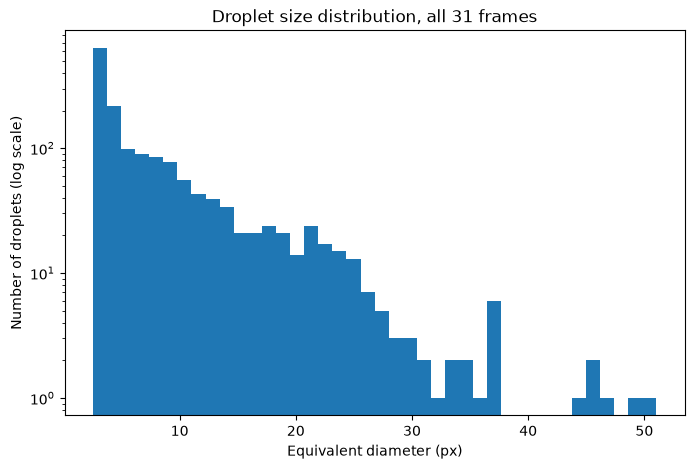

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_all["equiv_diameter_px"], bins=40)
plt.yscale("log")
plt.xlabel("Equivalent diameter (px)")
plt.ylabel("Number of droplets (log scale)")
plt.title("Droplet size distribution, all 31 frames")
plt.savefig("../data/size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
a = pd.read_csv("../data/droplets_per_object.csv")
b = pd.read_csv("../data/results_per_droplet.csv")
print(a.equals(b))

True


In [17]:
red = img_cv[:, :, 2]
mask = (red < 110).astype(np.uint8)
n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

jet_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
jet = labels == jet_label
print("jet area:", stats[jet_label, cv2.CC_STAT_AREA])

dist_to_jet = cv2.distanceTransform((~jet).astype(np.uint8), cv2.DIST_L2, 5)

jet area: 148604


In [18]:
df_droplets["dist_to_jet_px"] = df_droplets["id"].apply(
    lambda i: dist_to_jet[labels == i].min()
)
print(df_droplets["dist_to_jet_px"].round(1).value_counts().sort_index().head(15))
print(df_droplets["dist_to_jet_px"].describe().round(1))

dist_to_jet_px
2.0    7
2.2    1
2.8    1
3.0    6
4.0    2
4.2    1
5.0    3
5.2    1
6.0    1
7.0    4
7.2    1
8.0    1
8.4    1
8.6    1
9.2    1
Name: count, dtype: int64
count    42.0
mean      7.1
std       5.6
min       2.0
25%       3.0
50%       5.1
75%       9.0
max      24.8
Name: dist_to_jet_px, dtype: float64


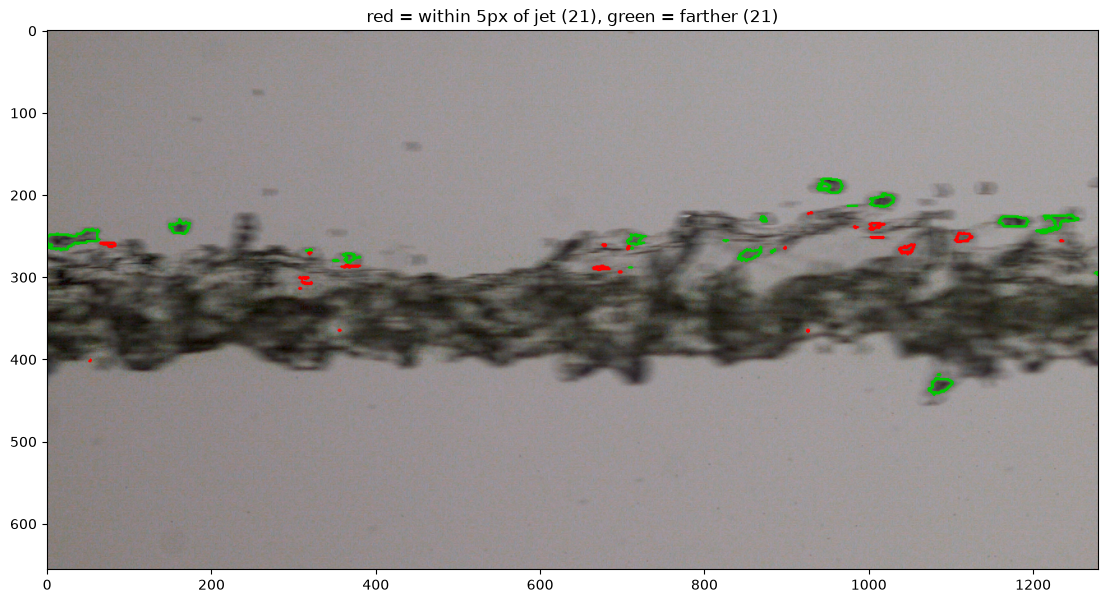

In [19]:
NEAR_PX = 5  # starting guess; adjust after looking at the table

overlay = img_cv.copy()
for _, row in df_droplets.iterrows():
    m = (labels == int(row["id"])).astype(np.uint8)
    cs, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    color = (0, 0, 255) if row["dist_to_jet_px"] <= NEAR_PX else (0, 200, 0)
    cv2.drawContours(overlay, cs, -1, color, 2)

n_near = (df_droplets["dist_to_jet_px"] <= NEAR_PX).sum()
plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(
    f"red = within {NEAR_PX}px of jet ({n_near}), green = farther ({len(df_droplets) - n_near})"
)
plt.show()

In [20]:
df_droplets["near"] = df_droplets["dist_to_jet_px"] <= NEAR_PX
print(df_droplets.groupby("near")["area_px"].describe().round(1))

       count   mean    std  min   25%   50%    75%    max
near                                                     
False   21.0  179.9  236.4  5.0  11.0  42.0  334.0  953.0
True    21.0   35.6   46.3  5.0   8.0  10.0   45.0  164.0


In [21]:
for t in [3, 5, 8, 12, 20]:
    print(t, (df_droplets["dist_to_jet_px"] <= t).sum(), "droplets within", t, "px")

3 15 droplets within 3 px
5 21 droplets within 5 px
8 29 droplets within 8 px
12 35 droplets within 12 px
20 39 droplets within 20 px


In [22]:
a = pd.read_csv("../data/droplets_per_object.csv")
b = pd.read_csv("../data/droplets_with_distance.csv")
print(a.equals(b[a.columns]))
print((b[b["filename"] == "Img000000.tif"]["dist_to_jet_px"] <= 5).sum())

for t in [3, 5, 8]:
    print(t, (b["dist_to_jet_px"] <= t).sum(), "of", len(b))

per_frame = b.groupby("filename").agg(
    all_droplets=("id", "size"),
    far_only=("dist_to_jet_px", lambda s: (s > 3).sum()),
)
print(per_frame.describe().round(1))

True
21
3 409 of 1583
5 591 of 1583
8 754 of 1583
       all_droplets  far_only
count          31.0      31.0
mean           51.1      37.9
std            10.8      10.2
min            29.0      17.0
25%            43.0      28.5
50%            50.0      36.0
75%            61.0      47.0
max            72.0      54.0
